# MSD Postselection Experiment

This notebook wires together the experimental `PostSelectionExperiment`
scaffold for three cases:

- distilled MSD with an MLD table decoder,
- distilled MSD with an MLE decoder,
- injected-state tomography with a degenerate no-ancilla MLD table decoder.

The default shot counts are intentionally small so the notebook can run as a
smoke test. Increase the constants below to approach the paper-scale curves.



In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
from bloqade.lanes import GeminiLogicalSimulator

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "demo":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from bloqade.gemini.decoding.workflow import plot_decoder_curves

from demo.msd_utils.application.experiments import (
    PostSelectionExperiment,
    empty_logical_circuit,
    magic_state_dist_steane,
    single_qubit_state_tomography,
)
from demo.msd_utils.application.experiments_helpers import (
    construct_confidence_decoders_mld,
    construct_confidence_decoders_mle,
    construct_full_factory_decoders_mld,
    construct_full_factory_decoders_mle,
)
from demo.msd_utils.standard.tomography import DEFAULT_TARGET_BLOCH



## Configuration



In [2]:
# TODO: maybe not have all the variables defined near the top? -- make dependencies clear between variables and functions

EVAL_SHOTS = 1_000_000
MLD_TRAIN_SHOTS = 10_000_000
MLD_RANK_TRAIN_SHOTS = 10_000_000
MLD_BATCH_SIZE = None
# TODO: subclass a device object
SIM_TYPE = "clifft"

BINARY_PRECISION = 4
# TODO: put these below in a different cell for configurations (for analysis configurations)
THRESHOLD_POINTS = 24
MIN_ACCEPTED_PER_BASIS = 50

SPECIAL_KERNEL_STRATEGY = "compiled_inverse_prefix"
# TOTALK: variable names in functions
# TODO: remove these when I merge main in.
DISTILLED_SIGN_VECTOR = (1.0, 1.0, 1.0)
INJECTED_SIGN_VECTOR = (1.0, 1.0, 1.0)

MSD_VALID_FACTORY_TARGETS = np.array([[1, 0, 1, 1]], dtype=np.uint8)
INJECTED_VALID_FACTORY_TARGETS = np.zeros((1, 0), dtype=np.uint8)



## Shared kernels



In [3]:
# TODO: check if we want to use dataclass or named tuple
primitive_set = magic_state_dist_steane()
noncliff_prefix = primitive_set.state_injection_circuit
main_cliff_circ = primitive_set.logical_circuit
# TODO: down the line, dictionary is OK, but a mapping from Pauli Strings to whatever. Can support normal strings
# can change the paulidict for now.
tomo_circs = single_qubit_state_tomography()



Building MSD primitives...


## Experiment construction



In [4]:
def build_msd_mld_experiment() -> PostSelectionExperiment:
    return PostSelectionExperiment(
        noncliff_prefix,
        main_cliff_circ,
        # TODO: allow for injection for tomography. have a default for single-qubit. -- delete tomo_circs, and document the assumption what tomography is being used.
        # TODO: note that in the future, we can add more tomography types.
        tomo_circs,
        MSD_VALID_FACTORY_TARGETS,
        construct_confidence_decoders_mld,
        # TODO: this should be the actual type
        construct_full_factory_decoders_mld,
        # TODO: this should be the arguments to pass in to the decoder constructor
        {
            "mld_train_shots": MLD_TRAIN_SHOTS,
            # TODO: can remove
            "mld_rank_train_shots": MLD_RANK_TRAIN_SHOTS,
            # TODO: use defaults.
            "batch_size": MLD_BATCH_SIZE,
            # TODO: can remove
            "sim_type": SIM_TYPE,
        },
        # TODO: can get rid of this
        target_bloch=DEFAULT_TARGET_BLOCH,
    )


def build_msd_mle_experiment() -> PostSelectionExperiment:
    return PostSelectionExperiment(
        noncliff_prefix,
        main_cliff_circ,
        tomo_circs,
        MSD_VALID_FACTORY_TARGETS,
        # TODO: get rid of this
        construct_confidence_decoders_mle,
        # TODO: substitute this with the type
        construct_full_factory_decoders_mle,
        # TODO: get rid of "sim_type" arg here and make target_bloch an empty numpy array.-- actually, get rid of target_bloch arg.
        {"sim_type": SIM_TYPE},
        target_bloch=DEFAULT_TARGET_BLOCH,
    )


def build_injected_mld_experiment() -> PostSelectionExperiment:
    return PostSelectionExperiment(
        noncliff_prefix,
        empty_logical_circuit(),
        tomo_circs,
        INJECTED_VALID_FACTORY_TARGETS,
        # TODO: get rid of confidence part
        construct_confidence_decoders_mld,
        # TODO: be the type of the tabledecoder
        construct_full_factory_decoders_mld,
        {
            # TODO: in principle, reduce the number of arguments passed in here?
            "mld_train_shots": MLD_TRAIN_SHOTS,
            # TODO: get rid of this
            "mld_rank_train_shots": MLD_RANK_TRAIN_SHOTS,
            "batch_size": MLD_BATCH_SIZE,
            # TODO: can remove sim_type
            "sim_type": SIM_TYPE,
        },
        # TODO: remove b/c we don't do ranking the way they do it in the paper
        target_bloch=DEFAULT_TARGET_BLOCH,
    )

# TODO: skip the function; just call the constructor.
msd_mld_exp = build_msd_mld_experiment()
msd_mle_exp = build_msd_mle_experiment()
injected_mld_exp = build_injected_mld_experiment()



## End-to-end runner



In [5]:
def prepare_experiment(
    exp: PostSelectionExperiment,
    *,
    decoder_name: str,
    num_logical_qubits: int,
    eval_shots: int = EVAL_SHOTS,
) -> PostSelectionExperiment:
    # TODO: "Exp" object should have good visualization methods -- defends why we are making it stateful -- for the future.
    exp.kernels(
        # TODO: drop num_logical_qubits --> looking through the kernels, and figuring out the number of qubits, etc. -- can be skippable.
        num_logical_qubits=num_logical_qubits,
        # TODO: can hardcode the output_qubit to 0.
        output_qubit=0,
        special_kernel_strategy=SPECIAL_KERNEL_STRATEGY,
    )
    exp.dem_circuits(special_kernel_strategy=SPECIAL_KERNEL_STRATEGY)
    exp.dems()
    exp.initialize_decoders()
    exp.prep_decoders()
    exp.make_tasks(device=GeminiLogicalSimulator())
    # TODO: get rid of SIM_TYPE
    exp.get_samples(num_shots=eval_shots, chunk_size=None, sim_type=SIM_TYPE)
    # TODO: get this from "introspection"?
    exp.decode_and_postselect(decoder_name=decoder_name)
    return exp

In [6]:
injected_mld_exp = prepare_experiment(
    injected_mld_exp,
    decoder_name="Injected MLD",
    num_logical_qubits=1,
)

100%|██████████| 153/153 [00:00<00:00, 6768.72it/s]


Sampling MLD ranking data for X with 10,000,000 shots...
cached MLD ranking data
Sampling MLD ranking data for Y with 10,000,000 shots...
cached MLD ranking data
Sampling MLD ranking data for Z with 10,000,000 shots...
cached MLD ranking data


Injected MLD X: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

Injected MLD Y: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

Injected MLD Z: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

In [7]:
injected_summary = injected_mld_exp.tomography_result(
    1.0,
    "wilson",
    sign_vector=INJECTED_SIGN_VECTOR,
    binary_precision=BINARY_PRECISION,
).fidelity_bloch(DEFAULT_TARGET_BLOCH)

In [8]:
injected_summary

{'point': 0.965355286621953,
 'median': 0.965355286621953,
 'low': 0.9645445283410496,
 'high': 0.9661660449028564,
 'error': 0.0008107582809033949,
 'bloch': (0.65449, 0.651714, 0.305834)}

In [9]:
msd_mld_exp = prepare_experiment(
    msd_mld_exp,
    decoder_name="MLD",
    num_logical_qubits=5,
)

try:
    msd_mle_exp = prepare_experiment(
        msd_mle_exp,
        decoder_name="MLE",
        num_logical_qubits=5,
    )
except Exception as exc:
    print(f"Skipping MLE experiment because decoder construction failed: {exc!r}")
    msd_mle_exp = None


100%|██████████| 153/153 [00:00<00:00, 179.05it/s]


Sampling MLD ranking data for X with 10,000,000 shots...
cached MLD ranking data
Sampling MLD ranking data for Y with 10,000,000 shots...
cached MLD ranking data
Sampling MLD ranking data for Z with 10,000,000 shots...
cached MLD ranking data


MLD X: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

MLD Y: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

MLD Z: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

Restricted license - for non-production use only - expires 2027-11-29


MLE X: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

MLE Y: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

MLE Z: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

Restricted license - for non-production use only - expires 2027-11-29


## Tomography result API



In [10]:
# NOTE: this should just have the shot counts.
tomo_result = msd_mld_exp.tomography_result(
    0.05,
    "wilson",
    # TODO: get rid of DISTILLED_SIGN_VECTOR
    sign_vector=DISTILLED_SIGN_VECTOR,
    binary_precision=BINARY_PRECISION,
)

# tomo_result should be a density matrix
# TODO: can add more functions/type checks on the inptu later -- for the future.
tomo_result.fidelity_bloch(DEFAULT_TARGET_BLOCH)



{'point': 0.9857767597642635,
 'median': 0.9857767597642635,
 'low': 0.9692751537290494,
 'high': 1.0022783657994776,
 'error': 0.016501606035214146,
 'bloch': (0.5168542315162157, 0.5497512437810945, 0.6161745827984596)}

In [11]:
injected_summary = injected_mld_exp.tomography_result(
    1.0,
    "wilson",
    sign_vector=INJECTED_SIGN_VECTOR,
    binary_precision=BINARY_PRECISION,
).fidelity_bloch(DEFAULT_TARGET_BLOCH)

## Curves



In [12]:
msd_mld_curve = msd_mld_exp.analysis_f_vs_fraction(
    # TODO: remove the first two arguments.
    binary_precision=BINARY_PRECISION,
    sign_vector=DISTILLED_SIGN_VECTOR,

    target_bloch=DEFAULT_TARGET_BLOCH,
    threshold_points=THRESHOLD_POINTS,
    min_accepted_per_basis=MIN_ACCEPTED_PER_BASIS,
    # TODO: get rid of this argument completely -- introduce more things with a default arguments.
    uncertainty_backend="wilson",
)

# TODO: ancilla? (Put the ancilla confidence stuff in a draft PR -- remove the ancilla score stuff from final PR) -- keep the branch with the ancilla confidence somewhere, so that the code is not lost.
# TODO: have a default argument for the BINARY_PRECISION; make the demo notebook simpler
# TODO: hide the impl with a default argument if possible; in the demo notebook. -- on purpose
# one that is pedagogical and pretty, and another that is quickly to see all parameters.
msd_mle_curve = None
if msd_mle_exp is not None:
    msd_mle_curve = msd_mle_exp.analysis_f_vs_fraction(
        # TODO: remove the first two args
        binary_precision=BINARY_PRECISION,
        sign_vector=DISTILLED_SIGN_VECTOR,
        target_bloch=DEFAULT_TARGET_BLOCH,
        threshold_points=THRESHOLD_POINTS,
        min_accepted_per_basis=MIN_ACCEPTED_PER_BASIS,
        # TODO: get rid of this argument completely -- introduce more things with a default arguments.

        uncertainty_backend="wilson",
    )

injected_curve = injected_mld_exp.analysis_f_vs_fraction(
    # TODO: remove the first two args
    binary_precision=BINARY_PRECISION,
    sign_vector=INJECTED_SIGN_VECTOR,
    target_bloch=DEFAULT_TARGET_BLOCH,
    threshold_points=THRESHOLD_POINTS,
    min_accepted_per_basis=MIN_ACCEPTED_PER_BASIS,
    # TODO: get rid of this argument completely -- introduce more things with a default arguments.

    uncertainty_backend="wilson",
)



In [13]:
injected_summary

{'point': 0.965355286621953,
 'median': 0.965355286621953,
 'low': 0.9645445283410496,
 'high': 0.9661660449028564,
 'error': 0.0008107582809033949,
 'bloch': (0.65449, 0.651714, 0.305834)}

## Individual visualizations



Plotting decoder curves...
Plotting decoder curves...
Plotting decoder curves...


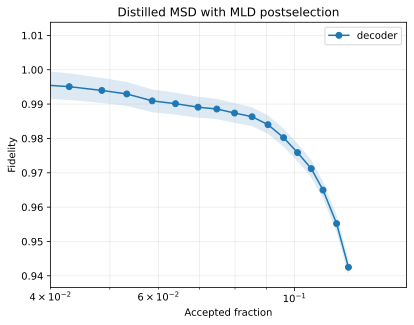

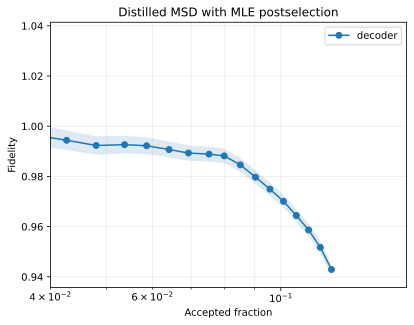

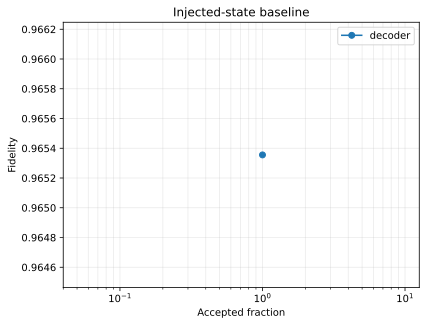

In [14]:
fig_mld, ax_mld = msd_mld_exp.analysis_visualization(
    min_accepted_fraction=0.04,
    title="Distilled MSD with MLD postselection",
)

if msd_mle_exp is not None:
    fig_mle, ax_mle = msd_mle_exp.analysis_visualization(
        min_accepted_fraction=0.04,
        title="Distilled MSD with MLE postselection",
    )

fig_injected, ax_injected = injected_mld_exp.analysis_visualization(
    min_accepted_fraction=0.04,
    title="Injected-state baseline",
)



## Combined figure



Plotting decoder curves...


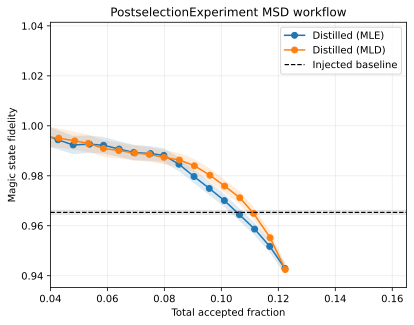

In [15]:
curves = {"Distilled (MLD)": msd_mld_curve}
if msd_mle_curve is not None:
    curves = {"Distilled (MLE)": msd_mle_curve, **curves}

fig, ax = plot_decoder_curves(
    curves,
    injected_summary=injected_summary,
    min_accepted_fraction=0.04,
    title="PostselectionExperiment MSD workflow",
)
ax.set_xscale("linear")
ax.set_xlabel("Total accepted fraction")
ax.set_ylabel("Magic state fidelity")
ax.legend()


# debug

In [16]:
import numpy as np

def summarize_curve(name, curve):
    print(f"\n{name}")
    print("keys:", curve.keys())

    for key in ["accepted_fraction", "fidelity", "credible", "low", "high", "median", "point", "error"]:
        if key not in curve:
            continue
        arr = np.asarray(curve[key])
        print(
            key,
            "shape=", arr.shape,
            "dtype=", arr.dtype,
            "min=", np.nanmin(arr) if arr.size else None,
            "max=", np.nanmax(arr) if arr.size else None,
        )

    credible = np.asarray(curve.get("credible", []), dtype=float)
    accepted = np.asarray(curve.get("accepted_fraction", []), dtype=float)
    fidelity = np.asarray(curve.get("fidelity", []), dtype=float)

    if credible.shape == (len(accepted), 2) and len(accepted):
        idx = int(np.nanargmin(credible[:, 0]))
        print("lowest credible interval row:")
        print("  idx:", idx)
        print("  accepted:", accepted[idx])
        print("  fidelity:", fidelity[idx])
        print("  low:", credible[idx, 0])
        print("  high:", credible[idx, 1])

summarize_curve("MLD", msd_mld_curve)

if msd_mle_curve is not None:
    summarize_curve("MLE", msd_mle_curve)

print("\ninjected_summary")
print(injected_summary)


MLD
keys: dict_keys(['accepted_fraction', 'fidelity', 'point_fidelity', 'credible'])
accepted_fraction shape= (19,) dtype= float64 min= 0.0015746666666666667 max= 0.12245366666666667
fidelity shape= (19,) dtype= float64 min= 0.9424949521678428 max= 0.9957639083784502
credible shape= (19, 2) dtype= float64 min= 0.9400912883723527 max= 1.0103196094815199
lowest credible interval row:
  idx: 18
  accepted: 0.12245366666666667
  fidelity: 0.9424949521678428
  low: 0.9400912883723527
  high: 0.944898615963333

MLE
keys: dict_keys(['accepted_fraction', 'fidelity', 'point_fidelity', 'credible'])
accepted_fraction shape= (19,) dtype= float64 min= 0.0003156666666666667 max= 0.12231566666666667
fidelity shape= (19,) dtype= float64 min= 0.94293364310207 max= 0.9966865026450786
credible shape= (19, 2) dtype= float64 min= 0.940529456383435 max= 1.0366199101718123
lowest credible interval row:
  idx: 18
  accepted: 0.12231566666666667
  fidelity: 0.94293364310207
  low: 0.940529456383435
  high: 0.

Plotting decoder curves...
ylim: (np.float64(0.9352648572823797), np.float64(1.0414463412617854))
collection 0 y min/max: 0.940529456383435 1.0366199101718123
collection 1 y min/max: 0.9400912883723527 1.0103196094815199
line 0 Distilled (MLE) y min/max: 0.94293364310207 0.9966865026450786
line 1 Distilled (MLD) y min/max: 0.9424949521678428 0.9957639083784502
line 2 Injected baseline y min/max: 0.965355286621953 0.965355286621953


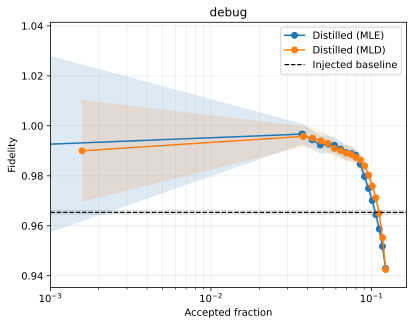

In [17]:
fig, ax = plot_decoder_curves(
    curves,
    injected_summary=injected_summary,
    min_accepted_fraction=0.001,
    title="debug",
)
print("ylim:", ax.get_ylim())

for i, collection in enumerate(ax.collections):
    try:
        paths = collection.get_paths()
        ys = np.concatenate([p.vertices[:, 1] for p in paths if len(p.vertices)])
        print("collection", i, "y min/max:", np.nanmin(ys), np.nanmax(ys))
    except Exception as exc:
        print("collection", i, "could not inspect:", exc)

for i, line in enumerate(ax.lines):
    y = np.asarray(line.get_ydata(), dtype=float)
    print("line", i, line.get_label(), "y min/max:", np.nanmin(y), np.nanmax(y))